RQ3 Plot: /home/wangshuo/resource/paper_figuires/combined_proxy_quality_cdf.pdf


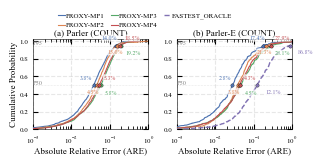

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


agg_mode = 'count'
TARGET_BUDGET = 0.1
MARK_PERCENTILES = [0.50, 0.95]


out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "combined_proxy_quality_cdf.pdf")


dataset_1 = 'dataset_three'
dataset_name_1 = 'Parler'
FASTEST_ORACLE_file_1 = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/efficiency"
path_fastest_oracle_1 = os.path.join(base_dir_1, FASTEST_ORACLE_file_1)
path_ablation_1 = os.path.join(base_dir_1, f"proxy_quality_ablation_{agg_mode}.csv")

RAW_PROXY_LABEL_MAP_1 = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}


dataset_2 = 'dataset_test'
dataset_name_2 = 'Parler-E'  
FASTEST_ORACLE_file_2 = f'FastestO_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON_2):
    T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/efficiency"
path_fastest_oracle_2 = os.path.join(base_dir_2, FASTEST_ORACLE_file_2)
path_ablation_2 = os.path.join(base_dir_2, "proxy_quality_multipred_ablation_count.csv")

RAW_PROXY_LABEL_MAP_2 = {
    "POSSA_Q4_Low": "PROXY-MP4",
    "POSSA_Q3_Med": "PROXY-MP3",
    "POSSA_Q2_High": "PROXY-MP2",
    "POSSA_Q1_Best": "PROXY-MP1",
}


DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP3",
    "PROXY-MP4",
    "FASTEST_ORACLE",
]


OFFSETS = {
    "PROXY-MP1": (-10, 4),   
    "PROXY-MP2": (-7, -6), 
    "PROXY-MP3": (3, -7), 
    "PROXY-MP4": (3, 4),     
    "FASTEST_ORACLE": (6, -6)     
}


plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # 标准 Times New Roman 字体
    "mathtext.fontset": "stix",  
    "font.size": 5.5,                   
    "axes.labelsize": 6.5,              
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.0,             
    "axes.linewidth": 0.4,              
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8              
})



def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

def load_data(t_true_path, ablation_path, fast_oracle_path, raw_label_map):
    with open(t_true_path, "r") as f:
        t_true_map = json.load(f)

    df_ablation = pd.read_csv(ablation_path)
    df_ablation = standardize_name(df_ablation)
    df_ablation = df_ablation[df_ablation["method"].isin(raw_label_map.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    df_ablation["method"] = df_ablation["method"].map(raw_label_map)

    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(t_true_map)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
    df_ablation = compute_are(df_ablation, "T_hat")

    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FASTEST_ORACLE":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    if os.path.exists(fast_oracle_path):
        df_fast = pd.read_csv(fast_oracle_path)
        df_fast = standardize_name(df_fast)
        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(t_true_map)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FASTEST_ORACLE"] = df_fast

    return data_map


data_map_1 = load_data(T_TRUE_JSON_1, path_ablation_1, path_fastest_oracle_1, RAW_PROXY_LABEL_MAP_1)
data_map_2 = load_data(T_TRUE_JSON_2, path_ablation_2, path_fastest_oracle_2, RAW_PROXY_LABEL_MAP_2)

fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.5))

palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

global_handles, global_labels = [], []
method_added = set()

def plot_cdf(ax, data_map, title, is_left=False):
    global global_handles, global_labels, method_added
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    positive_are = [x for x in all_are if x > 0]
    if positive_are:
        p2 = np.percentile(positive_are, 2)
        p98 = np.percentile(positive_are, 98)
        
        min_are = 10 ** np.floor(np.log10(p2)) if p2 > 0 else 1e-3
        upper_focus = 10 ** np.ceil(np.log10(p98)) if p98 > 0 else 1.0
        
        min_are = max(1e-4, min(1e-2, min_are))
        upper_focus = min(10.0, max(1.0, upper_focus))
    else:
        min_are = 1e-3
        upper_focus = 1.0

    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "--" if "FASTEST_ORACLE" in label else "-"
        lw = 1.0 if "FASTEST_ORACLE" in label else 0.8
        color = next(color_iter)

        line, = ax.plot(subset, y_vals, linewidth=lw, linestyle=ls, color=color, zorder=3)

        if label not in method_added:
            global_handles.append(line)
            global_labels.append(label)
            method_added.add(label)

        if MARK_PERCENTILES:
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                
                ax.scatter(val_x, p, color=color, s=6, zorder=4, edgecolors='black', linewidth=0.2)
                
                off_x, off_y = OFFSETS.get(label, (5, 5))
                
                # 🚨 【核心修改】：去除了 fontweight="bold"，与 RQ2 完全对齐
                ax.annotate(
                    f"{val_x * 100:.1f}%",
                    xy=(val_x, p),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=4.2,
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.08", fc="white", alpha=0.75, ec="none"),
                    zorder=5
                )

    ax.set_title(title, pad=3)
    ax.set_xlabel("Absolute Relative Error (ARE)", labelpad=1)
    
    ax.grid(True, which="major", linestyle="--", alpha=0.3)
    ax.grid(False, which="minor")

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    # 🚨 确保全部刻度和边框颜色纯黑向内
    ax.tick_params(direction='in', which='both', top=True, right=True, colors='black')

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.4)
        # 🚨 【核心修改】：去除了 P50/P95 文本的 fontweight="bold"
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=4.5)


plot_cdf(axes[0], data_map_1, "(a) Parler (COUNT)", is_left=True)
axes[0].set_ylabel("Cumulative Probability", labelpad=1)


plot_cdf(axes[1], data_map_2, "(b) Parler-E (COUNT)", is_left=False)


plt.subplots_adjust(top=0.82, bottom=0.22, left=0.18, right=0.92, wspace=0.25)

fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"RQ3 Plot: {out_pdf}")
plt.show()
plt.close(fig)